In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Đọc dữ liệu từ file CSV
df = pd.read_csv('Bank Customer Churn Prediction.csv')

# 2. Hiển thị 10 dòng đầu tiên để kiểm tra
print("10 dòng đầu tiên của tập dữ liệu:")
df.head(10)

10 dòng đầu tiên của tập dữ liệu:


,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
5,15574012,645,Spain,Male,44,8,113755.78,2,1,0,149756.71,1
6,15592531,822,France,Male,50,7,0.00,2,1,1,10062.80,0
7,15656148,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1
8,15792365,501,France,Male,44,4,142051.07,2,0,1,74940.50,0
9,15592389,684,France,Male,27,2,134603.88,1,1,1,71725.73,0


Thống kê số lượng Churn:
churn
0    7963
1    2037
Name: count, dtype: int64


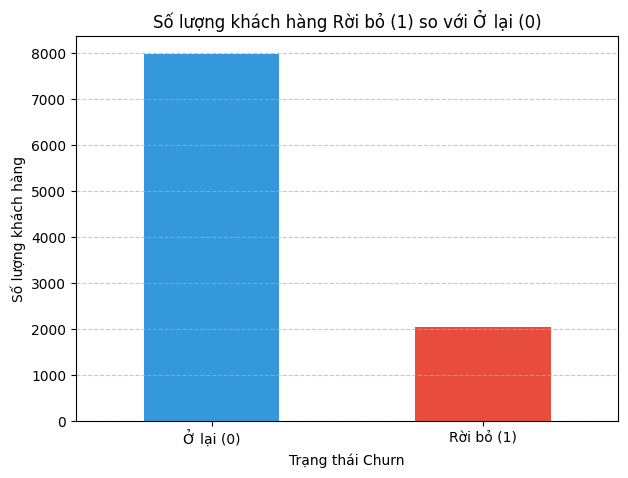

In [2]:
# 3. Thống kê số lượng khách hàng rời bỏ (1) và ở lại (0)
churn_counts = df['churn'].value_counts()
print("Thống kê số lượng Churn:")
print(churn_counts)

# Vẽ biểu đồ cột đơn giản
plt.figure(figsize=(7, 5))
churn_counts.plot(kind='bar', color=['#3498db', '#e74c3c'])
plt.title('Số lượng khách hàng Rời bỏ (1) so với Ở lại (0)')
plt.xlabel('Trạng thái Churn')
plt.ylabel('Số lượng khách hàng')
plt.xticks(ticks=[0, 1], labels=['Ở lại (0)', 'Rời bỏ (1)'], rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

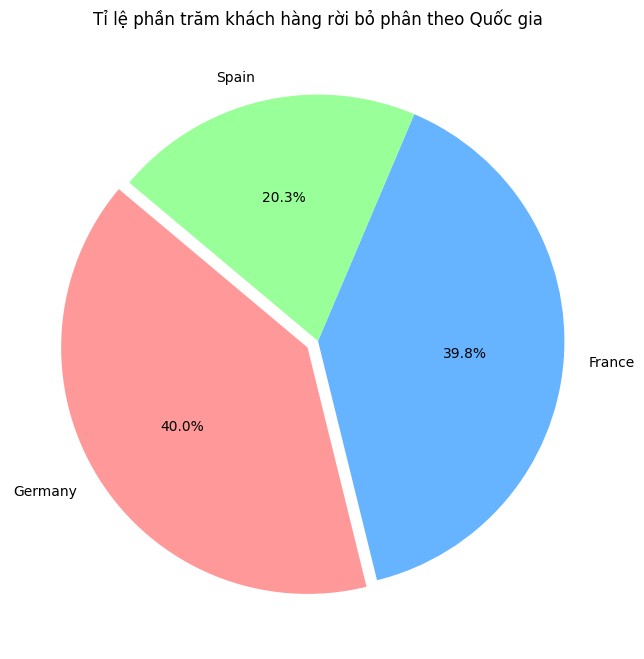

In [3]:
# 4. Lọc dữ liệu chỉ những khách hàng đã rời bỏ (churn == 1)
churn_only = df[df['churn'] == 1]

# Tính số lượng rời bỏ theo từng quốc gia
churn_by_country = churn_only['country'].value_counts()

# Vẽ biểu đồ tròn
plt.figure(figsize=(8, 8))
plt.pie(churn_by_country, labels=churn_by_country.index, autopct='%1.1f%%', 
        startangle=140, colors=['#ff9999','#66b3ff','#99ff99'], explode=[0.05, 0, 0])
plt.title('Tỉ lệ phần trăm khách hàng rời bỏ phân theo Quốc gia')
plt.show()

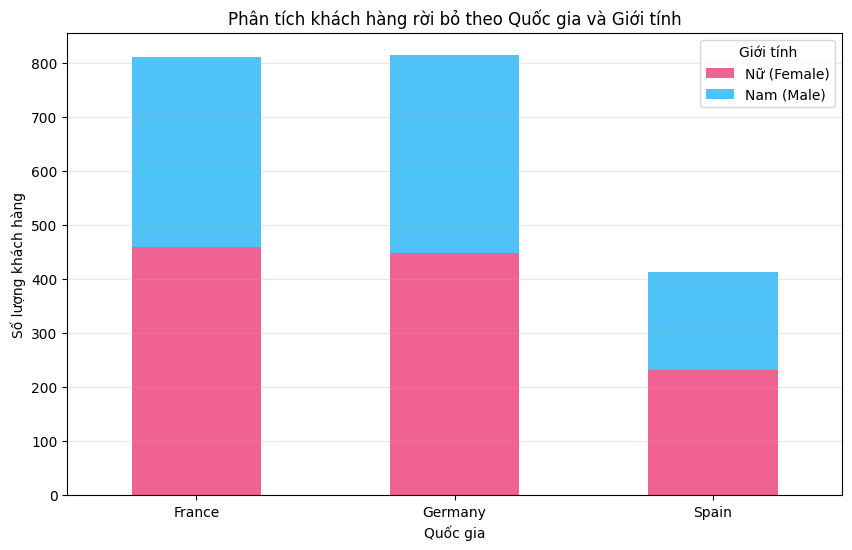

In [4]:
# Nhóm dữ liệu theo Quốc gia và Giới tính cho nhóm khách hàng rời bỏ
country_gender_data = churn_only.groupby(['country', 'gender']).size().unstack()

# Vẽ biểu đồ cột chồng (Stacked Bar Chart)
country_gender_data.plot(kind='bar', stacked=True, figsize=(10, 6), color=['#f06292', '#4fc3f7'])

plt.title('Phân tích khách hàng rời bỏ theo Quốc gia và Giới tính')
plt.xlabel('Quốc gia')
plt.ylabel('Số lượng khách hàng')
plt.legend(title='Giới tính', labels=['Nữ (Female)', 'Nam (Male)'])
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.show()

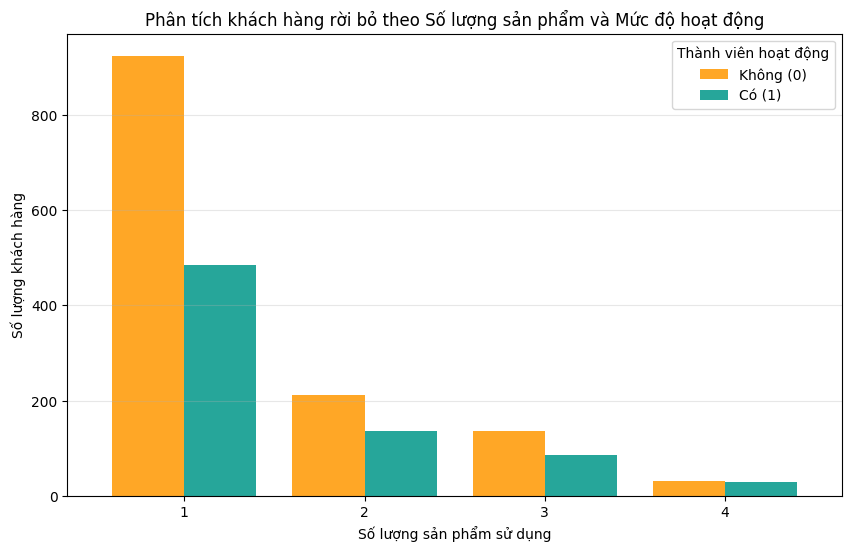

In [5]:
# Nhóm dữ liệu theo Số lượng sản phẩm và Trạng thái hoạt động cho nhóm rời bỏ
prod_active_data = churn_only.groupby(['products_number', 'active_member']).size().unstack()

# Vẽ biểu đồ cột nhóm (Grouped Bar Chart)
prod_active_data.plot(kind='bar', figsize=(10, 6), color=['#ffa726', '#26a69a'], width=0.8)

plt.title('Phân tích khách hàng rời bỏ theo Số lượng sản phẩm và Mức độ hoạt động')
plt.xlabel('Số lượng sản phẩm sử dụng')
plt.ylabel('Số lượng khách hàng')
plt.legend(title='Thành viên hoạt động', labels=['Không (0)', 'Có (1)'])
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.show()